# Random Accuracy and System Performance Tests

In [1]:
!pip -q install -U "transformers[torch]" pandas scikit-learn joblib matplotlib vaderSentiment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 124.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 139.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 whi

## Import libraries

In [ ]:
import os
import warnings
import time
import joblib
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from transformers import logging as transformers_logging
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

## Configurations and helper functions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
BASE_DIR = Path('/content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project')
OUTPUT_DIR = BASE_DIR / 'outputs/'
INPUT_CSV = BASE_DIR / 'data/preprocessed-data/corpus_no_train_or_eval.csv'
OUTPUT_CSV = OUTPUT_DIR / 'corpus_no_train_or_eval_predicted.csv'

TEXT_COL = 'text'
ML_TEXT_COL = 'text_ml'
TRANSFORMER_TEXT_COL = 'text_transformer'

ROBERTA_POL_COL = 'pred_roberta_polarity'
ROBERTA_SUB_COL = 'pred_roberta_subjectivity'
NB_SARCASM_POL_COL = 'pred_sarcasm_nb_polarity'
NB_SARCASM_SUB_COL = 'pred_sarcasm_nb_subjectivity'
NB_NER_POL_COL = 'pred_ner_nb_polarity'
NB_NER_SUB_COL = 'pred_ner_nb_subjectivity'
VADER_POL_COL = 'pred_vader_polarity'
VADER_SUB_COL = 'pred_vader_subjectivity'

def plot_label_distribution(series, title):
    counts = series.value_counts(dropna=False)
    ax = counts.plot(kind='bar', rot=0)
    ax.set_title(title)
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

## Multi-Task RoBERTa

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loaded Multi-Task RoBERTa model from: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/final_model
Device: cuda
System performance (Multi-Task RoBERTa):
 - Records inferred: 8628
 - Total inference time (s): 32.127
 - Throughput (records/sec): 268.56
 - Batch size: 32

Multi-Task RoBERTa polarity distribution:
pred_roberta_polarity
Neutral     4177
Negative    2536
Positive    1915
Name: count, dtype: int64


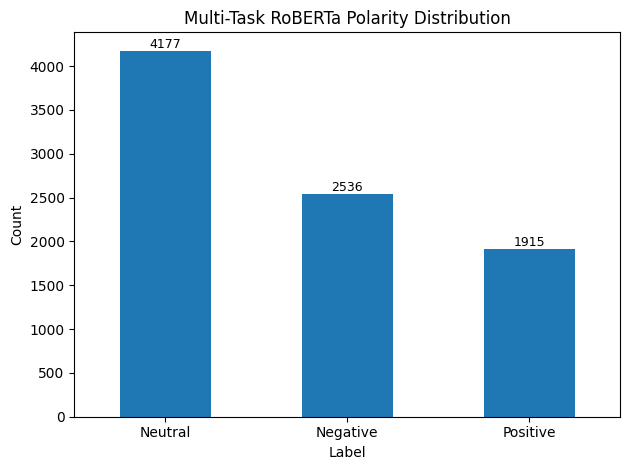


Multi-Task RoBERTa subjectivity distribution:
pred_roberta_subjectivity
Subjective    4375
Objective     4253
Name: count, dtype: int64


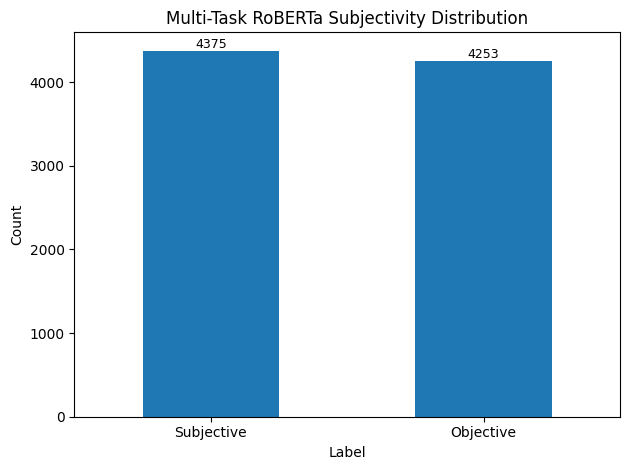

In [ ]:
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore", category=UserWarning)
transformers_logging.set_verbosity_error()

POLARITY_LABEL2ID = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
POLARITY_ID2LABEL = {v: k for k, v in POLARITY_LABEL2ID.items()}
SUBJECTIVITY_LABEL2ID = {'Objective': 0, 'Subjective': 1}
SUBJECTIVITY_ID2LABEL = {v: k for k, v in SUBJECTIVITY_LABEL2ID.items()}

ROBERTA_MODEL_PATH = OUTPUT_DIR / 'roberta_multitask_combined/final_model'
MAX_LENGTH = 384
BATCH_SIZE = 32

class RobertaForMultiTaskClassification(nn.Module):
    def __init__(self, model_name, polarity_num_labels, subjectivity_num_labels, dropout_prob=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout_prob)
        self.polarity_classifier = nn.Linear(hidden_size, polarity_num_labels)
        self.subjectivity_classifier = nn.Linear(hidden_size, subjectivity_num_labels)

    def forward(self, input_ids=None, attention_mask=None, **kwargs):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask, **kwargs)
        pooled = outputs.last_hidden_state[:, 0]
        pooled = self.dropout(pooled)

        polarity_logits = self.polarity_classifier(pooled)
        subjectivity_logits = self.subjectivity_classifier(pooled)
        return {'polarity_logits': polarity_logits, 'subjectivity_logits': subjectivity_logits}


# Load model/tokenizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(ROBERTA_MODEL_PATH / 'multitask_head.pt', map_location='cpu')

model = RobertaForMultiTaskClassification(
    model_name=checkpoint['model_name'],
    polarity_num_labels=len(checkpoint['polarity_label2id']),
    subjectivity_num_labels=len(checkpoint['subjectivity_label2id']),
)
model.load_state_dict(checkpoint['state_dict'])
model = model.to(device).eval()

tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_PATH)

print('Loaded Multi-Task RoBERTa model from:', ROBERTA_MODEL_PATH)
print('Device:', device)


# Random accuracy & system performance tests
def predict_multitask_texts(model, tokenizer, texts, batch_size=32, max_length=384):
    model.eval()
    all_pol, all_sub = [], []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors='pt',
            ).to(next(model.parameters()).device)

            out = model(**enc)
            all_pol.append(out['polarity_logits'].argmax(dim=-1).cpu().numpy())
            all_sub.append(out['subjectivity_logits'].argmax(dim=-1).cpu().numpy())

    return np.concatenate(all_pol), np.concatenate(all_sub)

# Load data with text_transformer
roberta_text_col = TRANSFORMER_TEXT_COL

df_test = pd.read_csv(INPUT_CSV, encoding='utf-8')
df_test[roberta_text_col] = df_test[roberta_text_col].fillna('').astype(str)

texts = df_test[roberta_text_col].tolist()
t0 = time.perf_counter()
pol_pred, sub_pred = predict_multitask_texts(
    model, tokenizer, texts, batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)
elapsed = time.perf_counter() - t0
records_per_sec = len(df_test) / max(elapsed, 1e-9)

# Save Multi-Task RoBERTa predictions
df_test[ROBERTA_POL_COL] = pd.Series(pol_pred).map(POLARITY_ID2LABEL)
df_test[ROBERTA_SUB_COL] = pd.Series(sub_pred).map(SUBJECTIVITY_ID2LABEL)

# Shared output dataframe
shared_df = df_test.copy()
shared_df[NB_SARCASM_POL_COL] = pd.NA
shared_df[NB_SARCASM_SUB_COL] = pd.NA
shared_df[NB_NER_POL_COL] = pd.NA
shared_df[NB_NER_SUB_COL] = pd.NA
shared_df[VADER_POL_COL] = pd.NA
shared_df[VADER_SUB_COL] = pd.NA
shared_df[ROBERTA_POL_COL] = df_test[ROBERTA_POL_COL].values
shared_df[ROBERTA_SUB_COL] = df_test[ROBERTA_SUB_COL].values

print('System performance (Multi-Task RoBERTa):')
print(f' - Records inferred: {len(df_test)}')
print(f' - Total inference time (s): {elapsed:.3f}')
print(f' - Throughput (records/sec): {records_per_sec:.2f}')
print(f' - Batch size: {BATCH_SIZE}')

print('\nMulti-Task RoBERTa polarity distribution:')
print(shared_df[ROBERTA_POL_COL].value_counts(dropna=False))
plot_label_distribution(shared_df[ROBERTA_POL_COL], 'Multi-Task RoBERTa Polarity Distribution')

print('\nMulti-Task RoBERTa subjectivity distribution:')
print(shared_df[ROBERTA_SUB_COL].value_counts(dropna=False))
plot_label_distribution(shared_df[ROBERTA_SUB_COL], 'Multi-Task RoBERTa Subjectivity Distribution')

## Multinomial Naive Bayes

In [ ]:
# load texts
df_ml = pd.read_csv(INPUT_CSV)
df_ml[ML_TEXT_COL] = df_ml[ML_TEXT_COL].fillna('').astype(str)
texts_ml = df_ml[ML_TEXT_COL].tolist()

### Multinomial Naive Bayes (Sarcasm)

System performance (Multinomial Naive Bayes Sarcasm):
 - Records inferred: 8628
 - Total inference time (s): 1.550
 - Throughput (records/sec): 5568.21

Naive Bayes Sarcasm polarity distribution:
pred_sarcasm_nb_polarity
Neutral     4886
Negative    3028
Positive     714
Name: count, dtype: int64


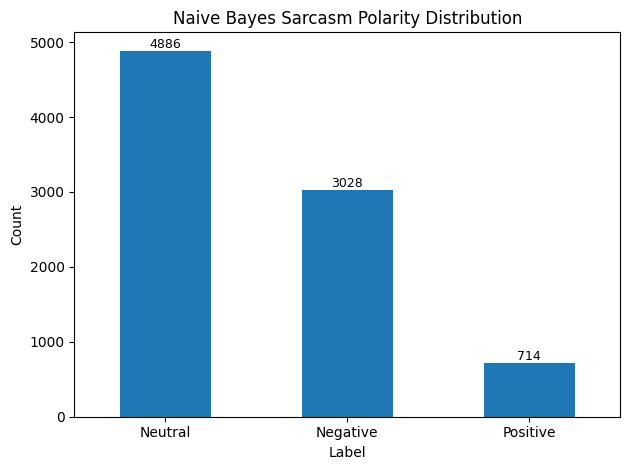


Naive Bayes Sarcasm subjectivity distribution:
pred_sarcasm_nb_subjectivity
Objective     6295
Subjective    2333
Name: count, dtype: int64


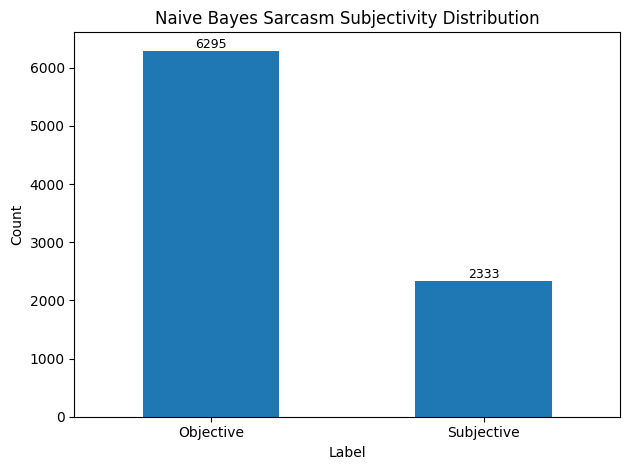

In [ ]:
# load saved nb model 
NB_POL_MODEL_PATH = OUTPUT_DIR / 'nb_polarity'/ 'NB_sarcasm_polarity.joblib'
NB_SUB_MODEL_PATH = OUTPUT_DIR / 'nb_subjectivity' / 'NB_sarcasm_subjectivity.joblib'

nb_pol_model = joblib.load(NB_POL_MODEL_PATH)
nb_sub_model = joblib.load(NB_SUB_MODEL_PATH)

_t0 = time.perf_counter() # Start timer
nb_pol_pred = nb_pol_model.predict(texts_ml)
nb_sub_pred = nb_sub_model.predict(texts_ml)
_nb_elapsed = time.perf_counter() - _t0 # Stop timer
_nb_rps = len(texts_ml) / max(_nb_elapsed, 1e-9)

shared_df[NB_SARCASM_POL_COL] = pd.Series(nb_pol_pred)
shared_df[NB_SARCASM_SUB_COL] = pd.Series(nb_sub_pred)

print('System performance (Multinomial Naive Bayes Sarcasm):')
print(f' - Records inferred: {len(texts_ml)}')
print(f' - Total inference time (s): {_nb_elapsed:.3f}')
print(f' - Throughput (records/sec): {_nb_rps:.2f}')

print('\nNaive Bayes Sarcasm polarity distribution:')
print(shared_df[NB_SARCASM_POL_COL].value_counts(dropna=False))
plot_label_distribution(shared_df[NB_SARCASM_POL_COL], 'Naive Bayes Sarcasm Polarity Distribution')

print('\nNaive Bayes Sarcasm subjectivity distribution:')
print(shared_df[NB_SARCASM_SUB_COL].value_counts(dropna=False))
plot_label_distribution(shared_df[NB_SARCASM_SUB_COL], 'Naive Bayes Sarcasm Subjectivity Distribution')

### Multinomial Naive Bayes (NER)

System performance (Multinomial Naive Bayes NER):
 - Records inferred: 8628
 - Total inference time (s): 1.517
 - Throughput (records/sec): 5686.84

Naive Bayes NER polarity distribution:
pred_ner_nb_polarity
Neutral     5173
Negative    2755
Positive     700
Name: count, dtype: int64


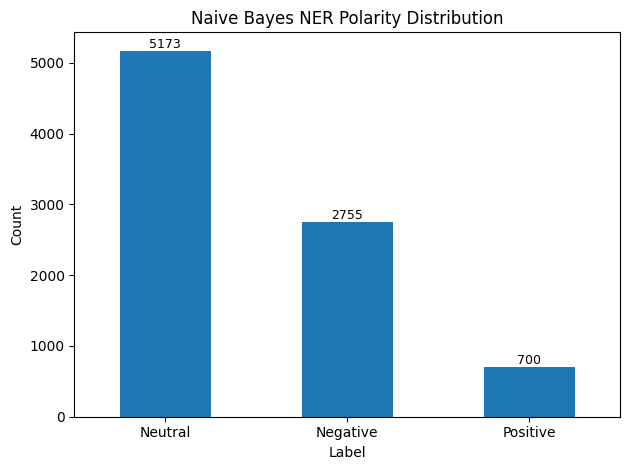


Naive Bayes NER subjectivity distribution:
pred_ner_nb_subjectivity
Objective     6324
Subjective    2304
Name: count, dtype: int64


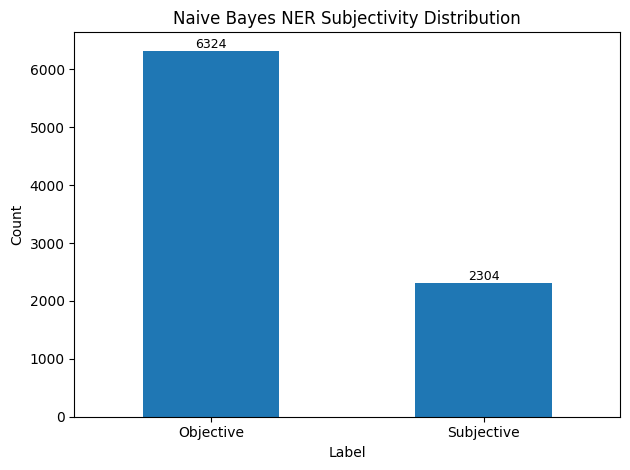

In [ ]:
# load saved nb model
NB_POL_MODEL_PATH = OUTPUT_DIR / 'nb_polarity'/ 'NB_NER_polarity.joblib'
NB_SUB_MODEL_PATH = OUTPUT_DIR / 'nb_subjectivity' / 'NB_NER_subjectivity.joblib'

nb_pol_model = joblib.load(NB_POL_MODEL_PATH)
nb_sub_model = joblib.load(NB_SUB_MODEL_PATH)

_t0 = time.perf_counter() # Start timer
nb_pol_pred = nb_pol_model.predict(texts_ml)
nb_sub_pred = nb_sub_model.predict(texts_ml)
_nb_elapsed = time.perf_counter() - _t0 # Stop timer
_nb_rps = len(texts_ml) / max(_nb_elapsed, 1e-9)

shared_df[NB_NER_POL_COL] = pd.Series(nb_pol_pred)
shared_df[NB_NER_SUB_COL] = pd.Series(nb_sub_pred)

print('System performance (Multinomial Naive Bayes NER):')
print(f' - Records inferred: {len(texts_ml)}')
print(f' - Total inference time (s): {_nb_elapsed:.3f}')
print(f' - Throughput (records/sec): {_nb_rps:.2f}')

print('\nNaive Bayes NER polarity distribution:')
print(shared_df[NB_NER_POL_COL].value_counts(dropna=False))
plot_label_distribution(shared_df[NB_NER_POL_COL], 'Naive Bayes NER Polarity Distribution')

print('\nNaive Bayes NER subjectivity distribution:')
print(shared_df[NB_NER_SUB_COL].value_counts(dropna=False))
plot_label_distribution(shared_df[NB_NER_SUB_COL], 'Naive Bayes NER Subjectivity Distribution')

## VADER

In [ ]:
# load texts
texts_vader = texts_ml
shared_df[ML_TEXT_COL] = df_ml[ML_TEXT_COL].values

Loaded VADER model
System performance (VADER):
 - Records inferred: 8628
 - Total inference time (s): 4.898
 - Throughput (records/sec): 1761.40

VADER polarity distribution:
pred_vader_polarity
Positive    5810
Negative    2017
Neutral      801
Name: count, dtype: int64


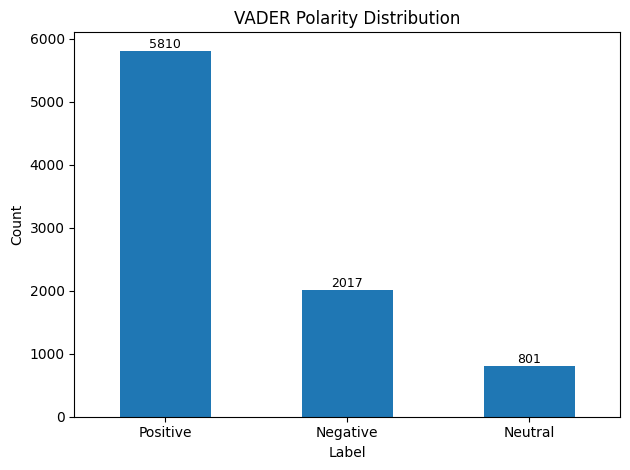


VADER subjectivity distribution:
pred_vader_subjectivity
Objective     5900
Subjective    2728
Name: count, dtype: int64


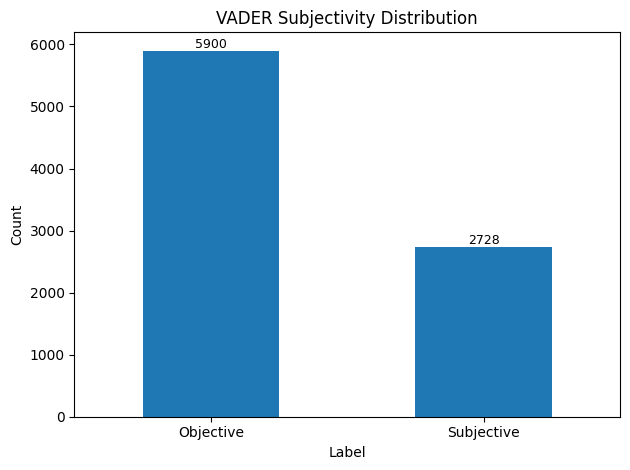

In [ ]:
# load VADER model
analyzer = SentimentIntensityAnalyzer()
print('Loaded VADER model')


def predict_vader(texts):
    pol_preds = []
    sub_preds = []
    for text in texts:
        scores = analyzer.polarity_scores(str(text))
        compound = scores['compound']
        neu = scores['neu']

        # Polarity
        if compound >= 0.05:
            pol_preds.append('Positive')
        elif compound <= -0.05:
            pol_preds.append('Negative')
        else:
            pol_preds.append('Neutral')

        # Subjectivity
        if neu >= 0.8:
            sub_preds.append('Objective')
        else:
            sub_preds.append('Subjective')

    return pol_preds, sub_preds

_t0 = time.perf_counter() # Start timer
vader_pol_pred, vader_sub_pred = predict_vader(texts_vader)
_vader_elapsed = time.perf_counter() - _t0 # Stop timer

shared_df[VADER_POL_COL] = vader_pol_pred
shared_df[VADER_SUB_COL] = vader_sub_pred

_vader_rps = len(texts_vader) / max(_vader_elapsed, 1e-9)
print('System performance (VADER):')
print(f' - Records inferred: {len(texts_vader)}')
print(f' - Total inference time (s): {_vader_elapsed:.3f}')
print(f' - Throughput (records/sec): {_vader_rps:.2f}')

print('\nVADER polarity distribution:')
print(shared_df[VADER_POL_COL].value_counts(dropna=False))
plot_label_distribution(shared_df[VADER_POL_COL], 'VADER Polarity Distribution')

print('\nVADER subjectivity distribution:')
print(shared_df[VADER_SUB_COL].value_counts(dropna=False))
plot_label_distribution(shared_df[VADER_SUB_COL], 'VADER Subjectivity Distribution')

## Save results

In [ ]:
required_prediction_cols = [
    ROBERTA_POL_COL,
    ROBERTA_SUB_COL,
    NB_SARCASM_POL_COL,
    NB_SARCASM_SUB_COL,
    NB_NER_POL_COL,
    NB_NER_SUB_COL,
    VADER_POL_COL,
    VADER_SUB_COL,
]

base_cols = ['doc_id', 'object_id', 'text', 'text_ml', 'text_transformer']
ordered_cols = base_cols + required_prediction_cols
final_export_df = shared_df[ordered_cols].copy()

FINAL_OUTPUT_CSV = OUTPUT_DIR / 'corpus_no_train_or_eval_predicted_all_models.csv'
FINAL_OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
final_export_df.to_csv(FINAL_OUTPUT_CSV, index=False)

print('Saved predictions to:', FINAL_OUTPUT_CSV)
print('\nColumns:')
print(list(final_export_df.columns))

Saved predictions to: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/corpus_no_train_or_eval_predicted_all_models.csv

Columns:
['doc_id', 'object_id', 'text', 'text_ml', 'text_transformer', 'pred_roberta_polarity', 'pred_roberta_subjectivity', 'pred_sarcasm_nb_polarity', 'pred_sarcasm_nb_subjectivity', 'pred_ner_nb_polarity', 'pred_ner_nb_subjectivity', 'pred_vader_polarity', 'pred_vader_subjectivity']


## Print prediction examples for discussion

In [ ]:
import pandas as pd

if "shared_df" not in globals():
    shared_df = pd.read_csv(
        OUTPUT_DIR / "corpus_no_train_or_eval_predicted_all_models.csv",
        encoding="utf-8",
    )

MAX_CHARS = 400

_POL = {0: "Negative", 1: "Neutral", 2: "Positive"}
_SUB = {0: "Objective", 1: "Subjective"}


def _pol(s):
    s = pd.Series(s).reset_index(drop=True)
    return s.map(_POL) if pd.api.types.is_numeric_dtype(s) else s.astype(str)


def _sub(s):
    s = pd.Series(s).reset_index(drop=True)
    return s.map(_SUB) if pd.api.types.is_numeric_dtype(s) else s.astype(str)


P_COLS = [ROBERTA_POL_COL, NB_SARCASM_POL_COL, NB_NER_POL_COL, VADER_POL_COL]
S_COLS = [ROBERTA_SUB_COL, NB_SARCASM_SUB_COL, NB_NER_SUB_COL, VADER_SUB_COL]
NAMES = ["RoBERTa", "NB_sarcasm", "NB_NER", "VADER"]

pol = pd.DataFrame({c: _pol(shared_df[c]) for c in P_COLS})
sub = pd.DataFrame({c: _sub(shared_df[c]) for c in S_COLS})

DISCUSSION = [
    (
        "All agree (polarity)",
        [
        "21ee5a99c7dd78c6a7b392ebad6f821534360a99",
        "318c0df4c83878b2af947f38807f0cb7b79c20fb",
        ],
    ),
    (
        "3 vs 1 (polarity)",
        [
            "022afb20f9e290298610fdaaa781d5d2273f43f4"
        ],
    ),
    (
        "2 vs 2 (polarity)",
        [
            "33b4525d2de3d1e70c8cb092bbe458144ae2a361",
        ],
    ),
]

import textwrap
# inside _print_row, after you build `tx`:


def _print_row(i, r):
    tx = r.get(TEXT_COL, r.get("text", ""))
    tx = "" if pd.isna(tx) else str(tx)
    # if len(tx) > MAX_CHARS:
    #     tx = tx[:MAX_CHARS] + "..."
    pol_s = "  ".join(f"{n}:{pol.loc[i, c]}" for n, c in zip(NAMES, P_COLS))
    sub_s = "  ".join(f"{n}:{sub.loc[i, c]}" for n, c in zip(NAMES, S_COLS))
    print(f"  doc_id={r.get('doc_id', '')}")
    for line in textwrap.wrap(tx, width=140, break_long_words=False, replace_whitespace=False):
      print(f"  {line}")
    # print(f"  {tx}")
    print(f"  pol: {pol_s}")
    print(f"  sub: {sub_s}")
    print()


_doc = shared_df["doc_id"].astype(str)
for title, doc_ids in DISCUSSION:
    print(title)
    for did in doc_ids:
        m = _doc == did
        if not m.any():
            print(f"  (missing doc_id={did})\n")
            continue
        i = shared_df.index[m][0]
        _print_row(i, shared_df.loc[i])

All agree (polarity)
  doc_id=21ee5a99c7dd78c6a7b392ebad6f821534360a99
  Using the Xiaomi 15 daily now, the screen is gorgeous and everything feels smooth. Also, the screen gets bright enough that I never struggle
  outside. It feels like a solid upgrade to me.
  pol: RoBERTa:Positive  NB_sarcasm:Positive  NB_NER:Positive  VADER:Positive
  sub: RoBERTa:Subjective  NB_sarcasm:Subjective  NB_NER:Subjective  VADER:Subjective

  doc_id=318c0df4c83878b2af947f38807f0cb7b79c20fb
  Last Year on My Mac: Look Back in Disbelief As an Android user since the T-Mobile G1, I tried switching to an iPhone 15 Pro as my primary
  phone from a carrier deal as the hardware looked nice plus Android/iOS has converged so much over the years with all the same apps available
  on either. I was pretty used to iOS from iPads and as a backup phone so the switching costs were minimal and the better MacOS integration
  seemed cool. But man, the notifications are a constant thorn in my side. I have missed so many wor